# 06 — Model Evaluation

## Smart India Real Estate Analytics

### Objective

The objective of this notebook is to perform the final evaluation of the selected property price prediction model.

The tuned HistGradientBoosting model selected during model training will be evaluated using the held-out test dataset.

The evaluation will include:

- Final regression metrics
- Actual vs predicted price analysis
- Residual/error analysis
- Prediction error distribution
- Model performance visualization
- Interpretation of model strengths and limitations

The test dataset will not be used for further model training or hyperparameter tuning.

## Evaluation Strategy

The final selected model was determined during `05_model_training.ipynb`.

The following artifacts will be loaded:

- `final_model.joblib` — selected trained model
- `preprocessor.joblib` — preprocessing transformer
- `X_test_processed.npz` — processed test features
- `y_test.csv` — test target values

The evaluation will be performed on the untouched test dataset to estimate how the model generalizes to unseen properties.

In [1]:
import numpy as np
import pandas as pd
import joblib

from pathlib import Path
from scipy import sparse

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt


MODEL_DIR = Path("../models")

print("Evaluation environment initialized.")

Evaluation environment initialized.


In [2]:
FINAL_MODEL_PATH = MODEL_DIR / "final_model.joblib"
PREPROCESSOR_PATH = MODEL_DIR / "preprocessor.joblib"

TEST_FEATURES_PATH = MODEL_DIR / "X_test_processed.npz"
TEST_TARGET_PATH = MODEL_DIR / "y_test.csv"

final_model = joblib.load(FINAL_MODEL_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)

X_test_processed = sparse.load_npz(TEST_FEATURES_PATH)

y_test = pd.read_csv(
    TEST_TARGET_PATH
)["Price"]

print("Final model loaded successfully.")
print("Preprocessor loaded successfully.")
print("Test features loaded successfully.")
print("Test target loaded successfully.")

print("\nTest features shape:", X_test_processed.shape)
print("Test target shape:", y_test.shape)

Final model loaded successfully.
Preprocessor loaded successfully.
Test features loaded successfully.
Test target loaded successfully.

Test features shape: (2905, 1738)
Test target shape: (2905,)


## Final Test Predictions

The saved final model will generate predictions for the held-out test dataset.

The test features were processed using the same preprocessing pipeline established during model development.

No model fitting or parameter tuning is performed in this notebook.

In [3]:
# Convert sparse test matrix to dense format required by HistGradientBoosting
X_test_final = X_test_processed.toarray().astype(np.float32)

print("Final test matrix shape:", X_test_final.shape)

final_predictions = final_model.predict(
    X_test_final
)

print("Final predictions generated successfully.")
print("Number of predictions:", len(final_predictions))

Final test matrix shape: (2905, 1738)
Final predictions generated successfully.
Number of predictions: 2905


## Final Model Performance

The final model is evaluated on the untouched test dataset using MAE, RMSE, and R².

These metrics provide the final quantitative assessment of the selected model's predictive performance on unseen properties.

In [4]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

final_metrics = {
    "MAE": final_mae,
    "RMSE": final_rmse,
    "R2": final_r2
}

print(f"Final MAE:  ₹{final_mae:,.2f}")
print(f"Final RMSE: ₹{final_rmse:,.2f}")
print(f"Final R²:   {final_r2:.4f}")

Final MAE:  ₹5,181,651.46
Final RMSE: ₹19,559,862.63
Final R²:   0.2175


## Actual vs Predicted Prices

An Actual vs Predicted scatter plot is used to visually assess prediction performance.

A perfectly accurate model would place all observations along the diagonal line:

`Predicted Price = Actual Price`

Points far from the diagonal represent larger prediction errors.

This visualization also helps identify whether the model systematically underpredicts or overpredicts particular price ranges.

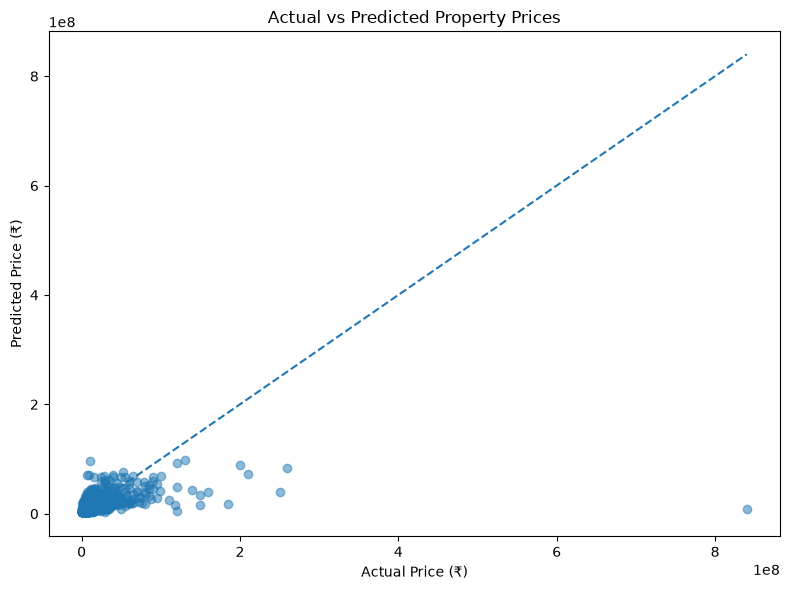

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

min_price = min(y_test.min(), final_predictions.min())
max_price = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted Property Prices")

plt.tight_layout()
plt.show()

## Log-Scale Actual vs Predicted Prices

Because property prices span a very wide range, a logarithmic scale is used to provide a clearer view of prediction performance across both lower- and higher-priced properties.

The logarithmic visualization does not change the model or evaluation metrics. It is used only to improve visual interpretation.

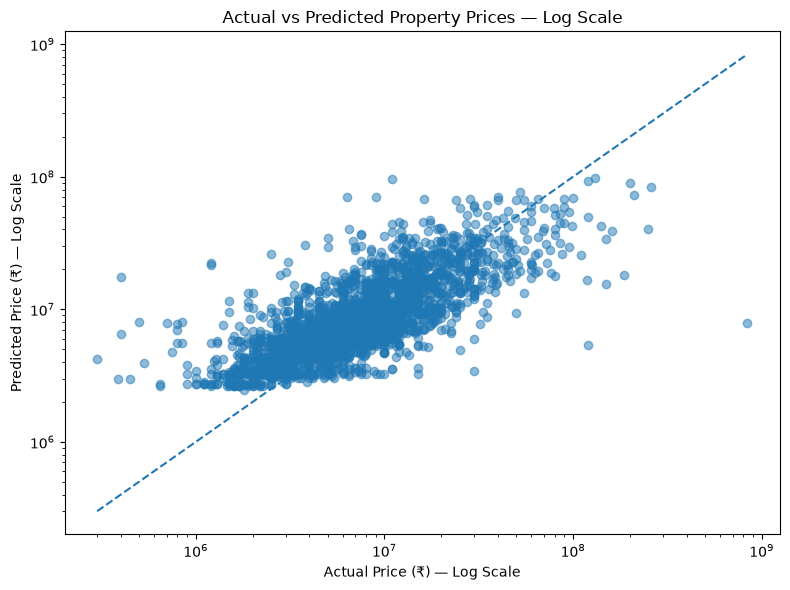

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

positive_min = min(
    y_test[y_test > 0].min(),
    final_predictions[final_predictions > 0].min()
)

positive_max = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [positive_min, positive_max],
    [positive_min, positive_max],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Price (₹) — Log Scale")
plt.ylabel("Predicted Price (₹) — Log Scale")
plt.title("Actual vs Predicted Property Prices — Log Scale")

plt.tight_layout()
plt.show()